# LSM Benchmarking with TCSPC

## Goal

The Leica SP8 confocal microscope is to be benchmarked using its hybrid photon detectors (HyDs) and the PicoQuant HydraHarp V2 as a means of read-out. It is to be determined 1.) how the photon data change over longer measurement periods either when fluorescence is recorded or no fluorescence species is scanned (dark counts) and 2.) what kind of performance can be expected from the white light laser source with and without using notch filters.


## Approach & Measurement Setup

**For 1.)**

The microscope is set up for a timeseries over several hours scanning a fluorescent species (fluoresceine) or no sample (dark counts) using the Leica LAS X ElectroPhysiology Wizzard. One frame is scanned every ten minutes with a scan speed of $100 \ Hz$. This behavior can be set up using so-called 'patterns' in the ElectroPhysiology Wizzard. The pattern were set up in the following way, because otherwise no frame and line markers are produced by the microscopes scan hardware:

$$\text{Job} \ 1_i \rightarrow \text{Pause}(10 \ \text{min})_i \rightarrow \text{Job} \ 2_i \ \text{for} \ i = 1 \ , ... \ , \ n$$

where $Job \ 1$ and $Job \ 2$ are scan processes and $Pause$ is a scan pause of 10 minutes. The pattern was repeated $n$ times, as indicated by $i$.



**For 2.)**



## Data Processing & Analysis
### Reading PicoQuant PTU Files
#### File Header Section

The resulting single-photon counting data were recorded using a PicoQuant HydraHarp V2 and saved as .ptu files. The .ptu file architecture is described [here](https://github.com/PicoQuant/PicoQuant-Time-Tagged-File-Format-Demos). 

Several functions are required to read and process .ptu files. First, a data stream from the file is created and the file magic sequence is checked, to confirm that the opened file a valid .ptu file (the first 8 bytes should read 'PQTTTR' in utf-8 encoding). The next 8 bytes encode the file version number.
Then, the file header section follows. A header entry is encoded with 48 bytes and consists of four data fields. Thus, after the file magic and version bytes, a while loop is set up that reads 48 byte chunks from the file and processes them until the 'header_end' tag is found. The header byte chunks (C structs) are structures as follows:

- Bits [0:32]
    - Tag ID: 'latin1' encoded string which acts as value descriptor
    - Tag ID is used as access variable to a header entries value 
    - Tag ID reads 'header_end' when the header section is finished; this is checked at the beginning of each header reading loop iteration
- Bits [32:36]
    - Tag Index: increments with reach header element; simply an index
- Bits [36:40]:
    - Tag Type indicator: ID which indicates the type of data to be expected from the tag value field
    - encoded as hex values, which need to be checked during dictionary of tag types in order to perform correct header value extraction
        - Empty: 0xFFFF0008
        - Bool: 0x00000008
        - Int8: 0x10000008
        - BitSet64: 0x11000008
        - Color8: 0x12000008
        - Float8: 0x20000008
        - DateTime: 0x21000008
        - Float8Array: 0x2001FFFF
        - ANSIString: 0x4001FFFF
        - WideString: 0x4002FFFF
        - BinaryBlob: 0xFFFFFFFF
- Bits [40:48]
    - actial tag value
    - Python's struct.unpack() function can be used for value extraction from bytes in big-endian notation
    - if tag type indicates an array, the tag value field indicates the number of following 8 bytes fields which contain the values of the array
    
From the while loop, the header contents are saved in a list. The most important header values are saved in FLIMInfo for quicker access:

- '\$Filename: filename
- '\$Comment': user comment
- 'TTResiltFormat_TTTRRecType': hex value indicating the photon counting hardware; 0x01010304 for HydraHarp V2; needs to be checked before photon data are procecssed; each counting hardware requires slightly differrent photon data processing
- '\$ReqHdr_SpatialResolution': pixel resolution in µm
- 'ImgHdr_PixX': number of pixels in x dimension
- 'ImgHdr_PixY': number of pixels in y dimension
- 'GlobalResolution': counting electrinics time resolution (16 ps / bin with 20 MHz laser repetition rate)
- 'HW_BaseResolution': principal resolution of couting hardware (kind of unimportant when I think about it)
- 'Resolution': 
- 'MeasDesc_BinningFactor': time axis binning factor
- 'TTResult_SyncRate': Laser repetition frequency
- 'TTResult_NumberOfRecords': number of HydraHarp system events (either photons or marker events); important to terminate following photon data section of ptu file; record reading can be terminated when 'NumberOfRecords'-times photon events were processed

The bitoffset in the .ptu file where the 'header_end' tag is located, is saved and used as a start point for reading and processing of photon records following the file header.


#### Decoding Photon Records and System Marker Events
After the 'header_end'tag, the photon data section of the file begins. In case of HydraHarp V2 data, the photon records consist of 4 byte (32 bit) chunks, which are structured in the following way:

- Bits [25:32]
    - Marker section
    - encodes system events and photon events
    - system event indicated with 'special bit' at position 32
        - if special bit is set, the event is a system event; either a frame/line marker or a macrotime clock overflow
        - if it is a frame or line marker, the 6 bit section without the special bit can read
            - 65 for line start
            - 66 for line stop
            - 70 for frame start
        - if the event is an overflow, all bits are set, i.e. the resulting value is 127
            - if it is 127, the nanotime section (see below) contains the number of overflows so far for; required for correction of macrotime 
    - if special bit is not set, the 6 bits after it indicate in which photon detector channel the photon was registered: 0, 1, 2, or 3
        - in that case, all folloing fields (macro and nanotime) encode the 'real' measurement values, i.e. the nano time of the photon relative to the synchronization signal and the macrotime (which needs to be converted to real time by overflow correction)
- Bits [10:25]
    - macrotime
    - encodes a linear time trace (real) time of the measurement
    - regularly overflows and needs to be corrected (see below: macrotime overflow correction) and converted to $s$ using the macrotime multiplication factor from the header
- Bits [0:10]
    - nanotime
    - encoded photon arrival time relative to the laser synchronization signals
    - accumulated over time to build fluorescence decay histogram
    - again, when special bit is set and overflow occured, this field contains number of macrotime clock overflows that occured so far in a measurement; this is required so that the macrotime trace can be corrected
    
In this Python script, the entire file is read into memory using Python's ```with open``` notation. The 'header_end' byte offset is used to position the file cue to the beginning of the photon record data. An array is pre-initialized with $n$ elements (```NumberOfRecords``` tag from header) with four fields using the appropriate data types. Each row in an array represents a single photon or system event.

    - ['record']: unsigned int32; holds raw 32 bit photon record chunks
    - ['marker']: unsigned int8; holds raw marker events; extracted from ['record’] by bitwise operation on ['record’] array
    - ['macrotime']: float32; holds macrotimes; extracted from ['record'] using the ```treatOverflows()``` function (see below)
    - ['nanotime']: float32; holds nanotimes; extractred from ['record’] by bitwise operation on ['record’] array
    
The ```recordarray``` array is set up using numpy with pre-defined data types.

```python
recordarray_datatypes = np.dtype([('record', np.uint32),
                                  ('marker', np.uint8),
                                  ('nanotime', np.float32),
                                  ('macrotime', np.float32)])

recordarray = np.zeros(shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

```

The values marker, nanotime and macrotime traces are extracted by performing bitwise-AND operations on the entire record['record'] array. This accesses highly performant numpy code and can be done in split seconds even for large measurement files. The corresponding values are stored in the pre-allocated fields in ```recordarray```.

```python
recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor

```
    
The 'real' macrotime values are extracted from the ['record'] array by using a Numba-accelerated function. This ```treatOverflows()``` function loops through each element and converts the macrotime values encoded in the bit field 10 to 25 to a float32. When the marker at a given position indicates an overflow (special bit set and channel markers indicate 127, i.e. are all set), an overflow correction variable is updated by adding the product of the macrotime at the overflow event with the overflow period (= 1024) to the previous value. Thus, in the next iteration the real macrotime can be recovered from the macrotime bit field by adding the macrotime correction variable with the macrotime in the bit field. The ```@njit``` decorator is used, this the function is compiled with Numba via Just-In-Time compilation for speed increase of the operation.

```python
@njit
def treatoverflows(recordarray, macrotimefactor):

    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            # Updating overflow correction value if overflow occured
            overflow_cor += overflow_period * (record['record') & (2**10 - 1))*macrotimefactor
            
        # Read macrotime value from record bits by bitwise right-shift
        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10 - 1))*macrotimefactor
        
    return(recordarray)

```


After the described operations were performed, ```recordarray``` contains the measurement traces in a easily accessible format and can be processed further in order to reconstruct the corresponding FLIM image etc.

### Reconstruction of FLIM images from ```recordarray```


In [1]:
%reset -f

# Importing modules
import sys, struct, io, os
import math
import numpy as np
from numba import jit
import scipy.signal as signal
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
%matplotlib inline

# Setting up matplotlib for larger plots and retina resolution
from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (10, 8)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16


# File path to .ptu file to be analysed
ptupath = '../notebooks/data/HyD_LongTime_Test_12.ptu'
#ptupath = '../app/testData/Convalaria_for_CC_6_1.ptu'
#ptupath = '../app/testData/Coumarin6_18_1.ptu'
#ptupath = '../notebooks/data/191126_DNA_FRETStandard_Lo_2_1.ptu'
#ptupath = '../notebooks/data/20191126_DNA-FRFET-Probe-high_stock_1_1.ptu'
#ptupath = '../notebooks/data/TK-E-R51_CMV-mCh-R54_120minNCS_7_1.ptu'
#ptupath = 'data/200115_Test_for_Line_markers11.ptu'
ptupath = 'data/20200115_Fluorsceine_Long_Scan.sptw/200115_Test_for_Line_markers1.ptu'
ptupath = 'data/200116_MicroscopeBenchmark_DarkCount.sptw/200116_MicroscopeBenchmark_DarkScan1.ptu'

In [2]:
# Functions for ptu record decoding
@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(
    recordarray: 4 x numRec NumPy array holding raw 32 bit photon records in ['record']
    macrotimefactor: multiplication factor for mactotime clock to recover real experiment macrotime
    )
    Output is recordarray, but with populated ['macrotime'] row
    
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
    return(recordarray)


In [3]:
# Record and header type definitions
tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

rtHydraHarp2T3 = struct.unpack(">i", bytes.fromhex('01010304'))[0]


#@jit(nopython = True, cache = True)
def readPTUData(path, makeFLIMInfo: bool = True):

    # Open file defined in ptupath
    ptureadstream = open(path, 'rb')

    # Checking file magic and version
    filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

    if(filemagic != 'PQTTTR'):
        print('%s is not a .ptu file!' % ptupath)
        ptureadstream.close()
    #else:
        #print('%s is a valid .ptu file... Commencing.' % ptupath)

    fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
    #print('File Version: %s' % fileversion)


    ## Decoding Header
    ## setting up header end string to terminate header decoding in while loop 
    headerend_tag = 'Header_End'
    reached_headerend = False


    # tuple that stores decoded information from header section
    header_contents = {}

    # decoding header
    while(reached_headerend == False):
        headerpiece = ptureadstream.read(48)
        tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
        tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
        tagType = struct.unpack('<i', headerpiece[36:40])[0]
        tagVal = headerpiece[40:48]

        if(tagId == headerend_tag):
            reached_headerend = True
            ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
            #print('Found Header_End.')
            break

        if(tagType == tyEmpty8):
            header_contents['Empty'] =  'Empty'

        elif(tagType == tyBool8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyInt8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8):
            value = struct.unpack('<d', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8Array):
            value = struct.unpack("<q", tagVal)[0]
            #print('Float array with %d entries' % value / 8)

        elif(tagType == tyAnsiString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('latin1').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyWideString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyBinaryBlob):
            value = struct.unpack("<q", tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyBitSet64):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyColor8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  "{0:#0{1}x}".format(value,18)

        elif(tagType == tyBinaryBlob):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyTDateTime):
            print('')

        else:
            continue
            #print('Unknown header tag type. Ignored.')


    headerend_bitoffset = ptureadstream.tell() # Needed to quickly jump to photon records instead of header

    #print('Finished decoding header.')

    # Copying header info into FLIMInfo dict
    FLIMInfo = {
        #'Filename' : header_contents['$Filename'],
        #'Comment': header_contents['$Comment'],
        'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
        'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
        #'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
        'PixelsX' : header_contents['ImgHdr_PixX'],
        'PixelsY' : header_contents['ImgHdr_PixY'],
        'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
        'BaseResolution' : header_contents['HW_BaseResolution'],
        'Resolution' : header_contents['MeasDesc_Resolution'],
        'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
        'SyncRate' : header_contents['TTResult_SyncRate'],
        'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
    }

    # Closing read stream
    ptureadstream.close()


    # Reading photon records from ptu file, reopening read stream at headerend_bitoffset
    ## Initializing record array with pre-defined data types and length (read from header -> NumberOfRecords)
    recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8),
                                  ('nanotime', np.float32), ('macrotime', np.float32)])
    recordarray = np.zeros(
            shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

    ## Getting macro and nano time conversion factors from FLIMInfo
    macroMultFactor = FLIMInfo['GlobalResolution']
    nanoMultFactor = FLIMInfo['Resolution'] * 1e9

    ## Dumping records into recordarray
    with open(path, 'rb') as file:
        file.seek(headerend_bitoffset)
        recordarray[:]['record'] = np.fromfile(file, dtype=np.uint32)
        file.close()

    ## Recover marker signals and nano times by bitwise operations on recordarray['record']
    recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
    recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor

    # Recover macro times using treatOverflows()
    recordarray = treatOverflows(recordarray, macroMultFactor)

    # Delete raw bit records from recordarray (['record'])
    macrotimes = np.array(recordarray['macrotime'], dtype = np.float64)
    nanotimes = np.array(recordarray['nanotime'], dtype = np.float64)
    markers = np.array(recordarray['marker'], dtype = np.uint8)
    #del recordarray

    #print('\n*********\nFinished decoding .ptu file. recordarray can now be used.')
    
    if(makeFLIMInfo == True):
        FLIMInfo = {
            'Filename' : header_contents['$Filename'],
            'Comment': header_contents['$Comment'],
            'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
            'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
            'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
            'PixelsX' : header_contents['ImgHdr_PixX'],
            'PixelsY' : header_contents['ImgHdr_PixY'],
            'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
            'BaseResolution' : header_contents['HW_BaseResolution'],
            'Resolution' : header_contents['MeasDesc_Resolution'],
            'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
            'SyncRate' : header_contents['TTResult_SyncRate'],
            'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
        }
        header_contents = FLIMInfo
    
    return(macrotimes, nanotimes, markers, header_contents)

## Data Analysis
### Fluoresceine Scan for 8 Hours

In [4]:
# Reading test data

#macrotimes, nanotimes, markers, header_contents = readPTUData('../notebooks/data/Fluoresceine Time Series/191214_Long_test_fluoresceine1.ptu', False)
#macrotimes, nanotimes, markers, header_contents = readPTUData('../notebooks/data/HyD_LongTime_Test_12.ptu', False)
#macrotimes, nanotimes, markers, header_contents = readPTUData('../notebooks/data/191126_DNA_FRETStandard_Lo_2_1.ptu')
macrotimes, nanotimes, markers, header_contents = readPTUData(ptupath, False)

In [5]:
# Checking the markers axis for all events
## 0 to 3 encode photon events, 65 and higher encode microscope (line, frame, ...) events, 127 is a macro time clock overflow
for i in range(0, 128):
    num = np.sum(markers == i)
    if(num != 0):
        print(num, "events for marker code ", i, ".")

5034445 events for marker code  0 .
12800 events for marker code  65 .
12751 events for marker code  66 .
1 events for marker code  68 .
49 events for marker code  70 .
4792685 events for marker code  127 .


In [6]:
# Calculatung length of macro time axis, Microscope was setup to scan one frame every five minutes and repeat that 30 times: 5 min * 30 = 2.5 h
## macrotime is in s! (CAVE: I converted the macrotimes array to s; in header it is in ms [see PQ PTU documentary!])´
timediff = (macrotimes[-1] - macrotimes[0])/(60**1)
print("Time difference between first and last macro time clock entry is ", round(timediff, 3), " minutes /", round(timediff/60, 3),"hours (", len(macrotimes), "macrotime entries).")

Time difference between first and last macro time clock entry is  594.621  minutes / 9.91 hours ( 9852731 macrotime entries).


In [7]:
# Calculating reasonable number of bins for macrotimes histogram -> 10 ms / bin
bins = int(macrotimes[-1]/0.1) # max macro time in s / 10 ms
print(bins)

### Marker event used for further analysis
selected_marker = 65

356772


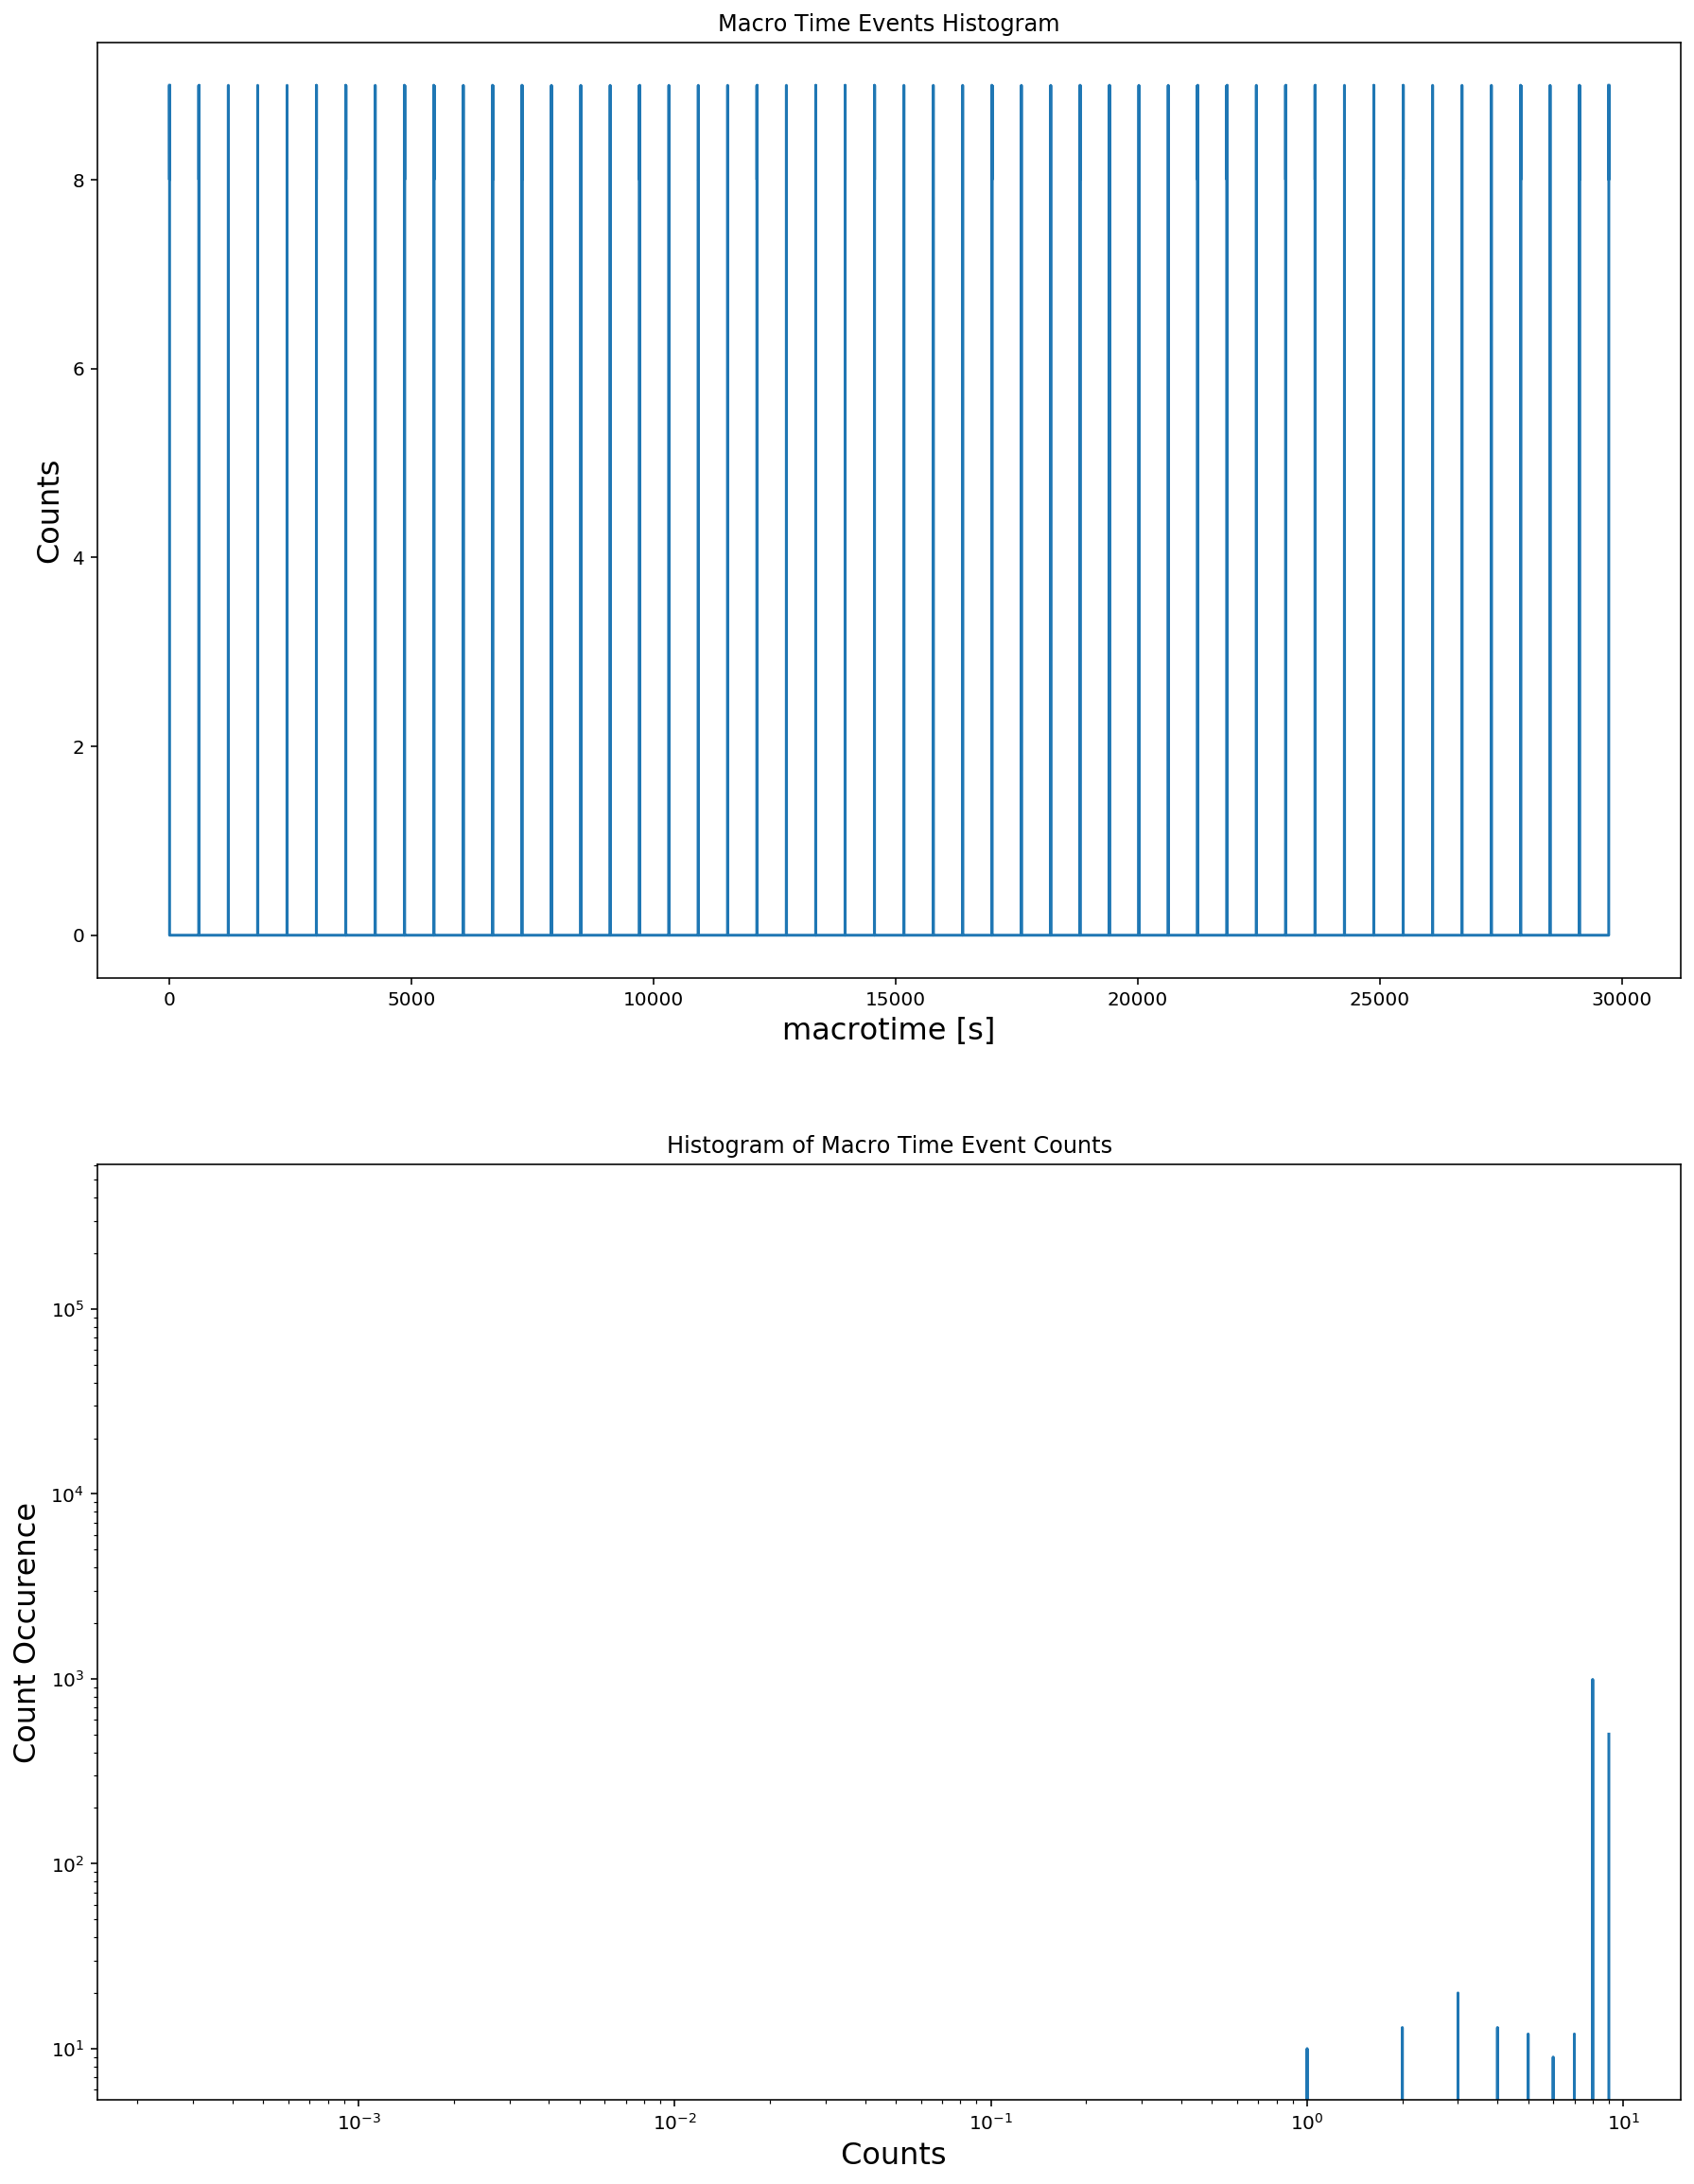

In [8]:
# Calculate macrotimes histogram for line start marker
macrotimes_hist_c1 = np.histogram(macrotimes[np.where(markers == selected_marker)], bins = bins)
macrotimes_eventfreq = np.histogram(macrotimes_hist_c1[0], bins = int(bins/10))

fig, axs = plt.subplots(2)
#fig.suptitle('Histograms: Macro Time Clock Events')
fig.set_size_inches(15, 20)
axs[0].plot(macrotimes_hist_c1[1][:-1], macrotimes_hist_c1[0], '-')
axs[0].set(title = 'Macro Time Events Histogram', ylabel = 'Counts', xlabel = 'macrotime [s]', yscale = 'linear')#, ylim = (0, 40e6))
axs[1].plot(macrotimes_eventfreq[1][:-1], macrotimes_eventfreq[0])
axs[1].set(title = 'Histogram of Macro Time Event Counts', ylabel = 'Count Occurence', xlabel = ' Counts', xscale = 'log', yscale = 'log')
plt.show()

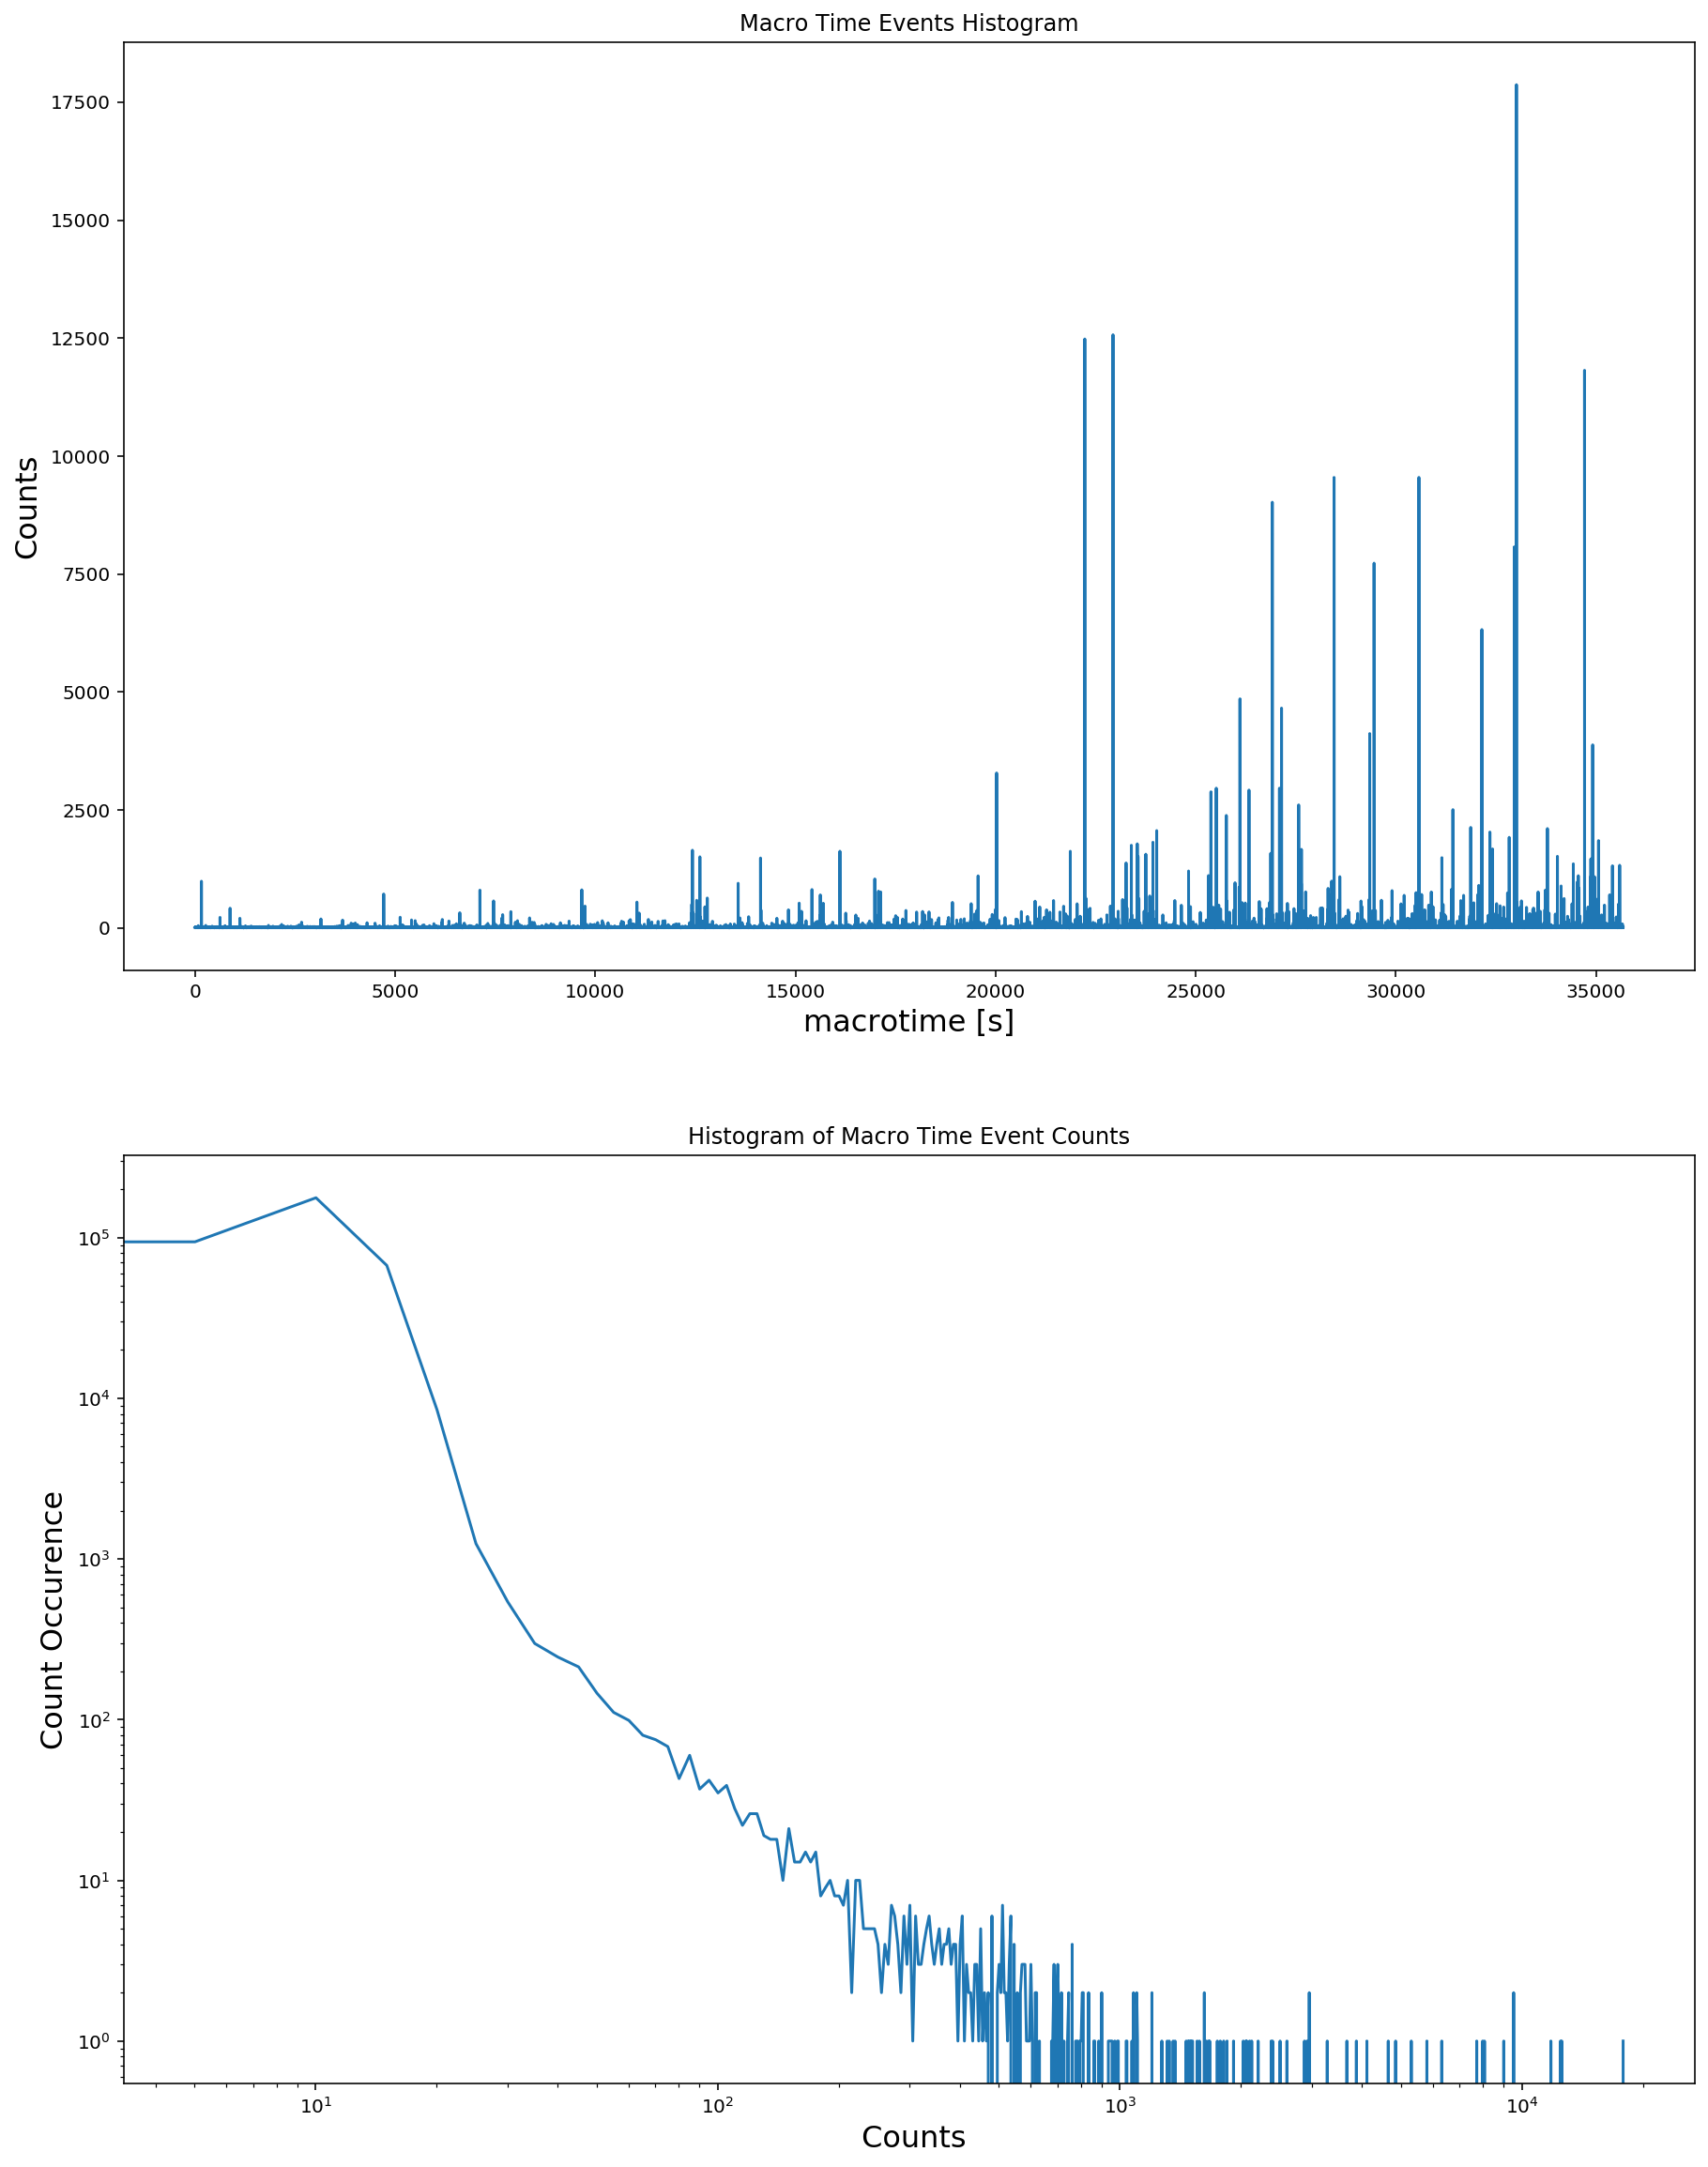

In [9]:
### Marker event used for further analysis
selected_marker = 0

# Calculate macrotimes histogram for channel 1
macrotimes_hist_c1 = np.histogram(macrotimes[np.where(markers == selected_marker)], bins = bins)
macrotimes_eventfreq = np.histogram(macrotimes_hist_c1[0], bins = int(bins/100))

fig, axs = plt.subplots(2)
#fig.suptitle('Histograms: Macro Time Clock Events')
fig.set_size_inches(15, 20)
axs[0].plot(macrotimes_hist_c1[1][:-1], macrotimes_hist_c1[0], '-')
axs[0].set(title = 'Macro Time Events Histogram', ylabel = 'Counts', xlabel = 'macrotime [s]', yscale = 'linear')#, ylim = (0, 40e6))
axs[1].plot(macrotimes_eventfreq[1][:-1], macrotimes_eventfreq[0])
axs[1].set(title = 'Histogram of Macro Time Event Counts', ylabel = 'Count Occurence', xlabel = ' Counts', xscale = 'log', yscale = 'log')
plt.show()

In [10]:
c1_selection = nanotimes
ns_hist_c1 = np.histogram(nanotimes[np.where(markers == 0)], bins = 3214)
#ns_hist_c1 = np.histogram(c1_selection, bins = 3214)
ns_hist_c2 = np.histogram(nanotimes[np.where(markers == 1)], bins = 3214)

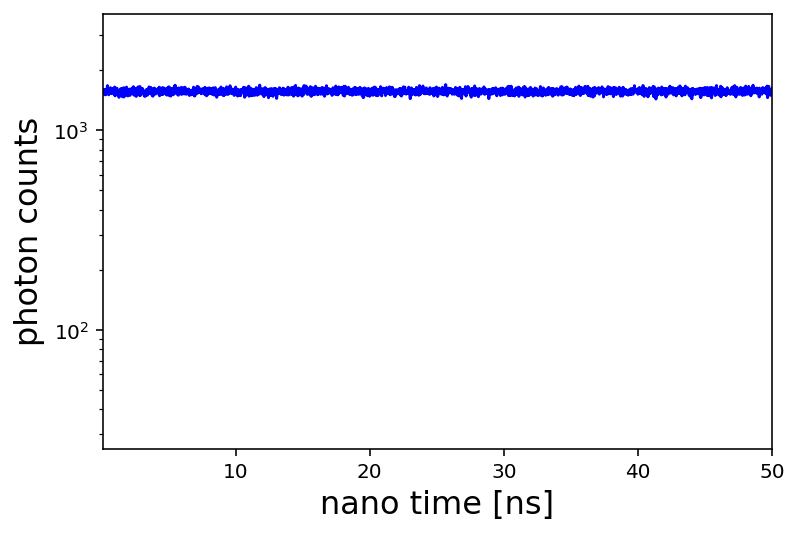

In [11]:
plt.plot(ns_hist_c1[1][:-1], ns_hist_c1[0], 'b-')
plt.xlim(0.1, 50)
#plt.ylim(0, 1000)
plt.yscale('log')
#plt.xticks(np.arange(0, 50, 1)) 
plt.xlabel('nano time [ns]')
plt.ylabel('photon counts')
plt.show()

#### Comparison of Signals 'In' a Line and 'Outside' of a Line


The goal of the following analysis is to compare the photon counting signal during the cause of the entire measurement (50 frames) and to show differences in counting rate: 1.) between 'in-line' photon signals (signals acquired while line marker is set) and 2.) between 'out-of-line' sigals (photon signals during the fly-back of the scan head).

First, the entire marker array is scanned for line start and line stop signals (65 and 66, respectively) and the corresponding value is set to 1. During the fly-back, the value in the array is set to 2. The newly created array can thus be used as a mask to seperate the signals during those events in the measurement file. 


In [16]:

frame_markers = np.where(
    np.logical_or(
        markers == 70, markers == 68 # Because I believe that the 68 marker is just a botched frame signal
    )
)[0]

# Replacing the 68 marker with 70
markers[np.where(markers == 68)] = 70


print(frame_markers.size, 'frame markers found in record array.\n')
# It's 100 frame markers, despite 50 frames; see beginning of this jupyter notebook

print(frame_markers)

''' It seems like theres only a frame marker at the beginning of the image,
so we need to count the number of line markers to dermine when a frame
scan has been completed. '''



# How many line signals are in-between two frame signals
counter_start = 0
counter_stop = 0 
for i in range(0, len(frame_markers) - 1):
    if((markers[frame_markers[i]:frame_markers[i + 1]] == 65).sum() == 256):
        counter_start += 1
    if((markers[frame_markers[i]:frame_markers[i + 1]] == 66).sum() == 255):
        counter_stop += 1
        
print("\n256/255 line marker elements were found", counter_start, "/", counter_stop, "times.")
'''
The line stop marker is a bit off. Only 255 line stop marker in 96 cases; others have 256...
'''

50 frame markers found in record array.

[   2502  144112  290956  436957  587163  735866  887234 1040839 1193534
 1346547 1499510 1655216 1810825 1967327 2122688 2275184 2432142 2587479
 2742285 2898591 3054860 3222250 3377266 3538614 3700185 3859474 4021961
 4181474 4340992 4501925 4662856 4821764 4981928 5151069 5309726 5472843
 5636127 5833939 6016074 6194637 6367738 6531840 6701754 6879640 7063145
 7286069 7470677 7656621 7822872 8012465]

256/255 line marker elements were found 49 / 48 times.


'\nThe line stop marker is a bit off. Only 255 line stop marker in 96 cases; others have 256...\n'

In [17]:
for element in header_contents:
    print(element, "\t\t", header_contents[element])

File_GUID 		 {40CAA249-9AD4-4581-8FE4-59E149067A22}
Measurement_SubMode 		 3
File_Comment 		 Leica set to Electrophysiolgy wizzard. Pattern: Job 1 --> Pause 10 min --> Job 2; GOTO Job 1 for 50 times. 

WLL set to 0 % global intensity. HyD1 set from 500 nm to 550 nm. 
TTResult_StopReason 		 1
Empty 		 Empty
CreatorSW_Name 		 SymPhoTime 64
CreatorSW_Version 		 2.1
CreatorSW_SVNBuild 		 3813
CreatorSW_Modules 		 0
ImgHdr_Dimensions 		 3
ImgHdr_Ident 		 3
ImgHdr_PixX 		 256
ImgHdr_PixY 		 256
ImgHdr_PixResol 		 0.911
ImgHdr_LineStart 		 1
ImgHdr_LineStop 		 2
ImgHdr_Frame 		 3
ImgHdr_BiDirect 		 0
ImgHdr_SinCorrection 		 80
Measurement_Mode 		 3
HW_Type 		 HydraHarp
HW_SerialNo 		 1024715
HW_Version 		 3.11
HW_ExternalRefClock 		 0
HW_Modules 		 4
HWModule_TypeCode 		 1040
HWModule_VersCode 		 18153994
HW_Markers 		 4
HWMarkers_Enabled 		 -1
HWMarkers_RisingEdge 		 0
HW_BaseResolution 		 9.999999960041972e-13
MeasDesc_BinningFactor 		 16
MeasDesc_Resolution 		 1.5999999936067155e-11
HWSync

In [18]:
'''
Loop through markers array and set element in line_indicator to,
if element is inbetween line start and stop signal and 2, when 
it occured during scan head fly-back. Because the marker '70'
indicates a frame, it can be used to terminate this and set the
line_indicator back to 0. line_indicator can then be used to 
select the corresponding elements by using it as a mask.
'''

from numba import njit

#@njit
def isolate_events(markers, nanotimes):
    frame_state = 0
    frame_counter = 0
    line_state = 0 # 0 for non-frame, 1 for in-line, 2 for out-of-line
    line_counter = 0
    in_line_nanotimes = []
    out_line_nanotimes = []
    tmp = []


    for i in range(0, len(markers)):
        if(markers[i] == 70):
            frame_state = 1
            continue

        while(frame_state == 1):
            if(markers[i] == 65):
                line_state = 1
                line_counter += 1
                continue
                
            if(frame_counter >= 256):
                frame_state = 0
                line_state = 0
                print('frame Finished')

            while(line_state == 1):
                if(markers[i] != 127):
                    tmp.append(nanotimes[i])

                if(markers[i] == 66):
                    line_state = 2
                    tmp = []
                    continue

            while(line_state == 2):
                if(markers[i] != 127):
                    tmp.append(nanotimes[i])

                if(markers[i] == 65):
                    line_state = 1
                    tmp = []
    
    return(in_line_nanotimes, out_line_nanotimes)

test1, test2 = isolate_events(markers, nanotimes)

KeyboardInterrupt: 

In [112]:
print(frame_counter)

2502


### Detrended Fluctuation Analysis
#### Description of the Method
(https://www.wikiwand.com/en/Detrended_fluctuation_analysis and https://www.nature.com/articles/srep00315.pdf)

Detrended fluctuation analysis (DFA) determines statisical 'self-affinity' of a signal, i.e. self-similarity. DFA can be used for non-stationary signals and is relateds to autocorrelation analysis.
Introduced by Peng et al., 1994 and is an extension of (ordinary) fluctation analysis.


DFA is done in two steps: first the 'sliding' mean difference of the timeseries is calculated. A given timeseries $X_t$ and its mean $\langle X \rangle$ within a given window is calculated over $k$ windows.

$$y(k) = \sum_{i = 1}^{k} \big[X_t(i) - \langle X \rangle \big]$$


Then, the data in each window output by $y(k)$ is fitted locally to a polynomial $y_{\Delta n} (k)$ (also often just linear fit). The mean-squared residuals $F(\Delta n)$ are calculated (which are the fluctutations) by

$$F(\Delta n) = \sqrt{\frac{1}{N} \sum_{k = 1}^{N} \big[ y(k) - y_{\Delta n}(k) \big]^2}$$

with $N$ as total number of data points. 





(Implementation adapted from https://github.com/dokato/dfa/blob/master/notebook/dfa_simulations.ipynb)

In [ ]:
def rms(x, scale):
    shape = (x.shape[0] / scale, scale)
    X = np.lib.stride

## Notch Filter Test
The pulsed white light laser (WLL) of the Leica SP8 system was tested for laser pulse bleed-through using an hybrid detector and the HydraHarp V2 TCSPC system. Laser emission was set to $488 \ nm$ and the detection edge of the hydrid detector was shifted from $500 \ nm$ to $498 \ nm$, $495 \ nm$, $493 \ nm$, $490 \ nm$, $489 \ nm$, $488 \ nm$, and $485 \ nm$ (total detection range of $50 \ nm$). During the first repetition, the notch filter for $488 \ nm$ was used, in the second repetition no notch filter was used.

The readPTUData() function, defined above, returns macro time, nano time, marker, and header arrays. The nano times are put in a histogram and plotted using the matplotlib module. The effect of the notch filter is shown.

In [290]:
# With Notfch Filter
wNF_500 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_1/191214_NFTest_488_wNF_1_1.ptu'))
wNF_500_hist = np.histogram(wNF_500[1][np.where(wNF_500[2] == 0)], bins = 3214)

wNF_495 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_2/191214_NFTest_488_wNF_2_1.ptu'))
wNF_495_hist = np.histogram(wNF_495[1][np.where(wNF_495[2] == 0)], bins = 3214)

wNF_493 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_3/191214_NFTest_488_wNF_3_1.ptu'))
wNF_493_hist = np.histogram(wNF_493[1][np.where(wNF_493[2] == 0)], bins = 3214)

wNF_490 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_4/191214_NFTest_488_wNF_4_1.ptu'))
wNF_490_hist = np.histogram(wNF_490[1][np.where(wNF_490[2] == 0)], bins = 3214)

wNF_489 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_5/191214_NFTest_488_wNF_5_1.ptu'))
wNF_489_hist = np.histogram(wNF_489[1][np.where(wNF_489[2] == 0)], bins = 3214)

wNF_488 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_6/191214_NFTest_488_wNF_6_1.ptu'))
wNF_488_hist = np.histogram(wNF_488[1][np.where(wNF_488[2] == 0)], bins = 3214)

wNF_485 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_7/191214_NFTest_488_wNF_7_1.ptu'))
wNF_485_hist = np.histogram(wNF_485[1][np.where(wNF_485[2] == 0)], bins = 3214)



# Without Notch Filter
woNF_500 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_9/191214_NFTest_488_woNF_9_1.ptu'))
woNF_500_hist = np.histogram(woNF_500[1][np.where(woNF_500[2] == 0)], bins = 3214)

woNF_495 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_11/191214_NFTest_488_woNF_11_1.ptu'))
woNF_495_hist = np.histogram(woNF_495[1][np.where(woNF_495[2] == 0)], bins = 3214)

woNF_493 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_12/191214_NFTest_488_woNF_12_1.ptu'))
woNF_493_hist = np.histogram(woNF_493[1][np.where(woNF_493[2] == 0)], bins = 3214)

woNF_490 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_13/191214_NFTest_488_woNF_13_1.ptu'))
woNF_490_hist = np.histogram(woNF_490[1][np.where(woNF_490[2] == 0)], bins = 3214)

woNF_489 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_14/191214_NFTest_488_woNF_14_1.ptu'))
woNF_489_hist = np.histogram(woNF_489[1][np.where(woNF_489[2] == 0)], bins = 3214)

woNF_488 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_15/191214_NFTest_488_woNF_15_1.ptu'))
woNF_488_hist = np.histogram(woNF_488[1][np.where(woNF_488[2] == 0)], bins = 3214)

woNF_485 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_16/191214_NFTest_488_woNF_16_1.ptu'))
woNF_485_hist = np.histogram(woNF_485[1][np.where(woNF_485[2] == 0)], bins = 3214)

In [291]:
#for k in wNF_485[3]:
#    print(k, wNF_485[3][k])


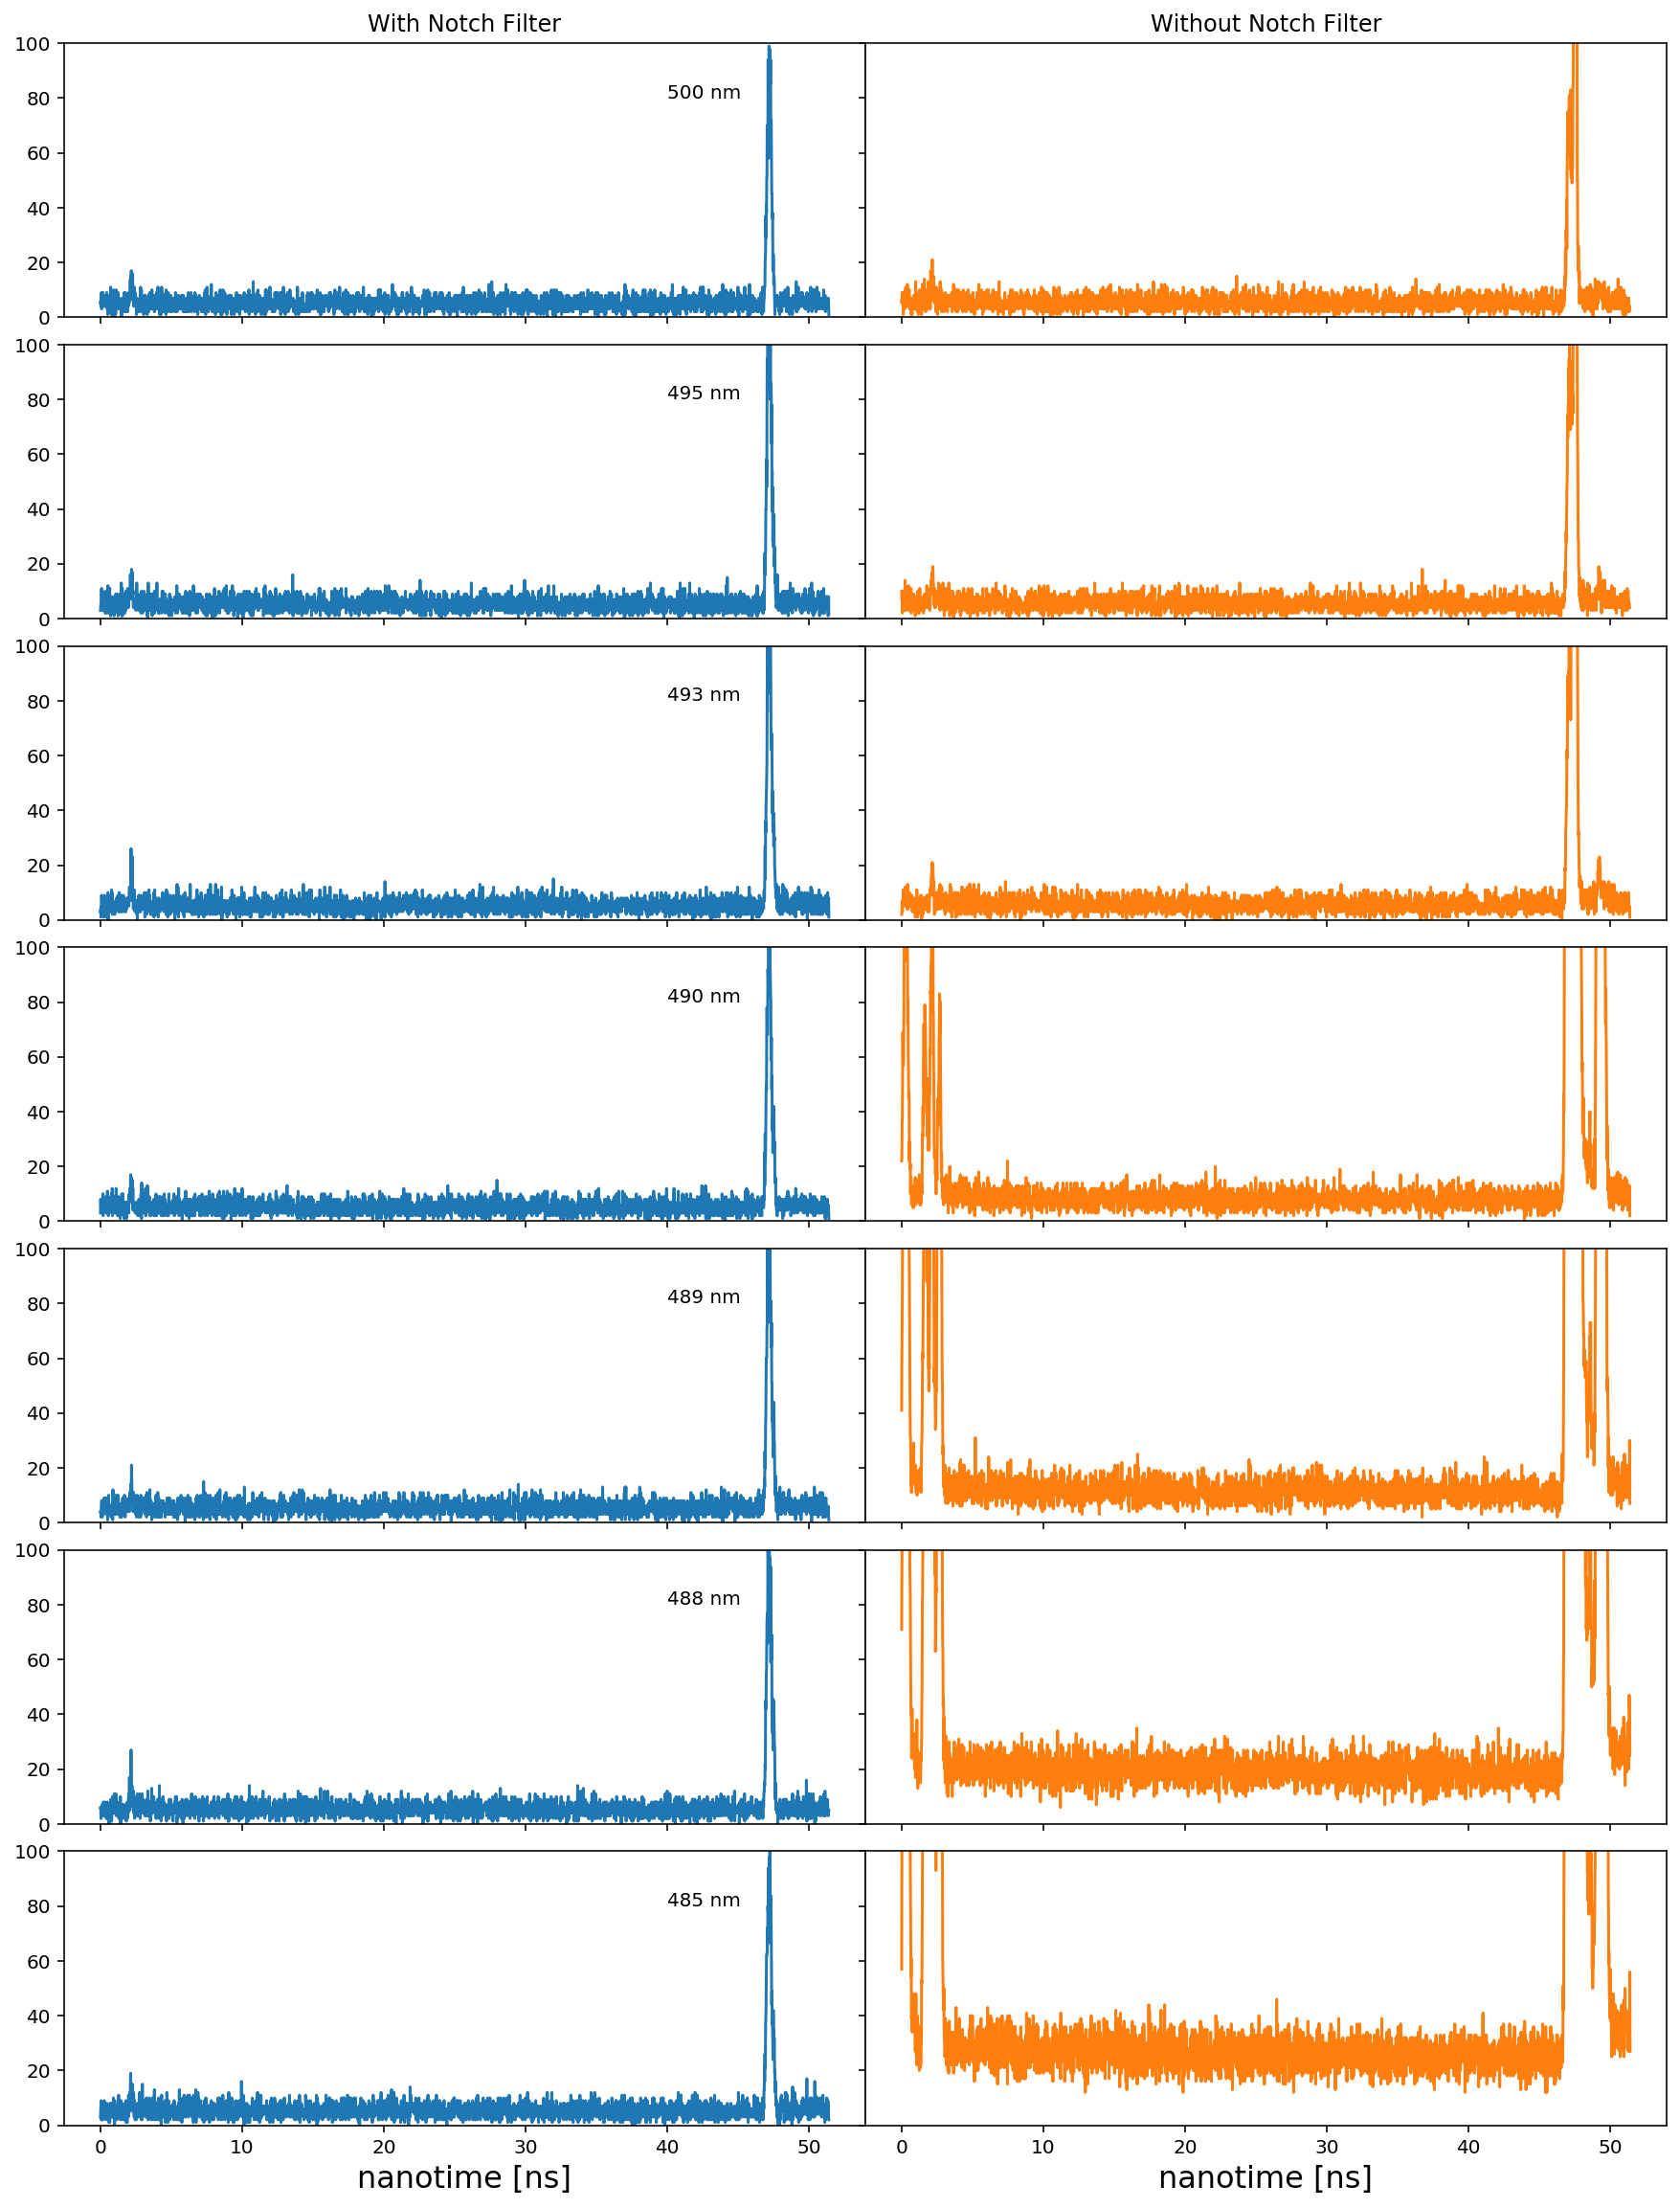

In [294]:
# Making subplots for peak visualization

yUpperLim = (0, 100)
yscale_set = 'linear'

fig, axs = plt.subplots(7, 2, sharex='col', sharey='row',
                        gridspec_kw={'hspace': 0.1, 'wspace': 0})
fig.set_size_inches(15, 20)

(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12), (ax13, ax14) = axs


ax1.plot(wNF_500_hist[1][:-1], wNF_500_hist[0])
ax1.set(ylim = yUpperLim, yscale = yscale_set)
ax1.set_title('With Notch Filter')
ax1.text(40, (0.8*yUpperLim[1]), '500 nm')
ax2.plot(woNF_500_hist[1][:-1], woNF_500_hist[0], 'tab:orange')
ax2.set(ylim = yUpperLim, yscale = yscale_set)
ax2.set_title('Without Notch Filter')


ax3.plot(wNF_495_hist[1][:-1], wNF_495_hist[0])
ax3.set(ylim = yUpperLim, yscale = yscale_set)
ax3.text(40, (0.8*yUpperLim[1]), '495 nm')
ax4.plot(woNF_495_hist[1][:-1], woNF_495_hist[0], 'tab:orange')
ax4.set(ylim = yUpperLim, yscale = yscale_set)

ax5.plot(wNF_493_hist[1][:-1], wNF_493_hist[0])
ax5.set(ylim = yUpperLim, yscale = yscale_set)
ax5.text(40, (0.8*yUpperLim[1]), '493 nm')
ax6.plot(woNF_493_hist[1][:-1], woNF_493_hist[0], 'tab:orange')
ax6.set(ylim = yUpperLim, yscale = yscale_set)

ax7.plot(wNF_490_hist[1][:-1], wNF_490_hist[0])
ax7.set(ylim = yUpperLim, yscale = yscale_set)
ax7.text(40, (0.8*yUpperLim[1]), '490 nm')
ax8.plot(woNF_490_hist[1][:-1], woNF_490_hist[0], 'tab:orange')
ax8.set(ylim = yUpperLim, yscale = yscale_set)

ax9.plot(wNF_489_hist[1][:-1], wNF_489_hist[0])
ax9.set(ylim = yUpperLim, yscale = yscale_set)
ax9.text(40, (0.8*yUpperLim[1]), '489 nm')
ax10.plot(woNF_489_hist[1][:-1], woNF_489_hist[0], 'tab:orange')
ax10.set(ylim = yUpperLim, yscale = yscale_set)

ax11.plot(wNF_488_hist[1][:-1], wNF_488_hist[0])
ax11.set(ylim = yUpperLim, yscale = yscale_set)
ax11.text(40, (0.8*yUpperLim[1]), '488 nm')
ax12.plot(woNF_488_hist[1][:-1], woNF_488_hist[0], 'tab:orange')
ax12.set(ylim = yUpperLim, yscale = yscale_set)

ax13.plot(wNF_485_hist[1][:-1], wNF_485_hist[0])
ax13.set(ylim = yUpperLim, xlabel = 'nanotime [ns]', yscale = yscale_set)
ax13.text(40, (0.8*yUpperLim[1]), '485 nm')
ax14.plot(woNF_485_hist[1][:-1], woNF_485_hist[0], 'tab:orange')
ax14.set(ylim = yUpperLim, xlabel = 'nanotime [ns]', yscale = yscale_set)

#plt.savefig('../notebooks/ns_plot_lin.pdf', format = 'pdf')
plt.show()

## Image Reconstruction of Notch Filter Test Series

In [148]:
# Functions for image reconstruction

#@jit(nopython = True)
def buildFLIMArray(recordarray, channel, linesinfile, pixelsx, pixelsy, globRes, timeRes, spatialBinning, temporalBinning):
    '''
    buildFLIMArray(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    - channel: int; which channel to reconstruct the flimarray from
    - pixelsx: original image dimension in X, stored in FLIMInfo
    - pixelsy: original image dimension in Y, stored in FLIMInfo
    - globRes: global measurment of nanotime, stored in FLIMInfo, in ns, 51 ns for 20 MHz laser pulse frequency
    - timeRes: nanotime resolution of TCSPC device, in ps
    - spatialBinning: user-defined binning factor of image, calculated as 2**factor
    - temporalBinning: user-defined binning factor for fluorescence decay histogram
    )
    '''

    eventCounter = 0  # Keeps track of photon / marker events while looping through data
    lineCounter = 0  # Stores current scan line numbers
    frameCounter = 0  # Stores current frame number
    # How many frames are in the image; assume square format
    framesInFile = linesinfile / pixelsx
    # Number of TCSPC bins based on time between pulses and TCSPC time resolution
    decayBins = math.floor((globRes / timeRes)/(2**temporalBinning))
    globalResolution = globRes * 10E8  # time between pulses in ns
    timeResolution = timeRes * 10E9  # TCSPC time resolution in nss

    binningFactor = 2**spatialBinning

    lineStart = 0
    lineStop = 0
    pixelTime = 0  # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lastLine = False
    # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)
    lineActive = False

    # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpEvents = [np.float64(x) for x in range(0)]
    # List storing photon nanotimes to assign to 3D-FLIM array in x-y position
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0  # Holds marker value for one loop iteration
    tmpMacro = 0  # Holds macrotime value for one loop iteration
    tmpNanotime = 0  # Holds nanotime value for one loop iteration
    diff = 0  # Stores difference between photon macro time and line start to determine photon y-position

    nPixelX = int(pixelsx / binningFactor)
    nPixelY = int(pixelsy / binningFactor)
    

    pixelIDX = 0  # Current x position in image
    pixelIDY = 0  # Current y position in image

    flimarray = np.zeros((nPixelX, nPixelY, decayBins), dtype=np.uint16)
    # 2D array for intensity image
    intensityImage = np.zeros((nPixelX, nPixelY), dtype=np.uint16)

    while(lastLine == False):
        tmpMarker = recordarray[2][eventCounter]

        if(tmpMarker == 65):  # Event is line start marker
            lineActive = True  # Starting line evaluation (next while loop)
            # Store line start time
            lineStart = recordarray[0][eventCounter]
            eventCounter += 1
            continue  # Skip this loop iteration

        while(lineActive == True):
            tmpMarker = recordarray[2][eventCounter]
            tmpMacro = recordarray[0][eventCounter]
            tmpNanotime = recordarray[1][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / (nPixelY)

                # Build intensity image and FLIM array from photon macro times
                for i in range(0, len(tmpEvents)):
                    diff = tmpEvents[i] - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    binID = math.floor((tmpNano[i]/globalResolution)*decayBins) - 1

                    if(pixelIDY < 0 or pixelIDY > (nPixelY - 1)):
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (nPixelY - 1)):
                            pixelIDY = nPixelY - 1

                    intensityImage[math.floor(pixelIDX)][pixelIDY] += 1
                    flimarray[math.floor(pixelIDX)][pixelIDY][binID] += 1

                pixelIDX = pixelIDX + (1/binningFactor)
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1
        
    #return flimarray, intensityImage
    return(intensityImage)

@jit(nopython=True, cache=True)
def reconstructImage(recordarray, channel, linesinfile, pixelsx, pixelsy):
    '''
    Function: reconstructImage(recordarray, channel, linesinfile, pixelsx, pixelsy) -> intensityImage [2D NumPy array; pixelsx x pixelsy]
    - recordarray [4D numpy array; record, marker, nanotime, macrotime]: TTTR data produced by PTUReader.py.PTUReader(path), macrotime overflows corrected
    - channel [int]: channel ID that should be used for image reconstruction, 0 to 3 for channels 1 to 4
    - linesinfile [int]: from FLIMInfo['LinesInFile] produces by PTUReader.py.countLines(recordarray), indicates number of line markers in TTTR data
    - pixelsx [int]: from FLIMInfo produced by PTUReader.PTUReader(), image dimension in X
    - pixelsy [int]: image dimension in Y
    '''

    eventCounter = 0  # Keeps track of photon / marker events while looping through data
    lineCounter = 0  # Stores current scan line numbers
    frameCounter = 0  # Stores current frame number
    # How many frames are in the image; assume square format
    framesInFile = linesinfile / pixelsx

    lineStart = 0
    lineStop = 0
    pixelTime = 0  # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lastLine = False
    # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)
    lineActive = False

    # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpEvents = [np.float64(x) for x in range(0)]
    # List storing photon nanotimes to assign to 3D-FLIM array in x-y position
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0  # Holds marker value for one loop iteration
    tmpMacro = 0  # Holds macrotime value for one loop iteration
    tmpNanotime = 0  # Holds nanotime value for one loop iteration
    diff = 0  # Stores difference between photon macro time and line start to determine photon y-position

    pixelIDX = 0  # Current x position in image
    pixelIDY = 0  # Current y position in image

    # 2D array for intensity image
    intensityImage = np.zeros((pixelsx, pixelsy), dtype=np.int16)

    while(lastLine == False):
        tmpMarker = recordarray[2][eventCounter]

        if(tmpMarker == 65):  # Event is line start marker
            lineActive = True  # Starting line evaluation (next while loop)
            # Store line start time
            lineStart = recordarray[0][eventCounter]
            eventCounter += 1
            continue  # Skip this loop iteration

        while(lineActive == True):
            tmpMarker = recordarray[2][eventCounter]
            tmpMacro = recordarray[0][eventCounter]
            tmpNanotime = recordarray[1][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / pixelsy

                for photon in tmpEvents:
                    diff = photon - lineStart
                    pixelIDY = math.floor(diff / pixelTime)

                    if(pixelIDY < 0 or pixelIDY > (pixelsy - 1)):
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (pixelsy - 1)):
                            pixelIDY = pixelsy - 1

                    intensityImage[pixelIDX][pixelIDY] = intensityImage[pixelIDX][pixelIDY] + 1

                pixelIDX = pixelIDX + 1
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1
        
        
    return intensityImage



#@jit(nopython=True)
def countLines(recordarray):
    '''
    Function: countLines(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    )
    
    - Counts number of line start (marker == 65) and line stop (marker == 66) events in raw photon data
    - Purpose: check data integrity
    '''

    numLinesStart = np.sum(recordarray[2] == 65)
    numLinesStop = np.sum(recordarray[2] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart

In [150]:
# testing the image reconstruction
woNF_485[3]['LinesInFile'] = countLines(woNF_485)
print(woNF_485[3]['LinesInFile'])

#flimarray, intimage = buildFLIMArray(woNF_485,
#                                     0,
#                                     woNF_485[3]['LinesInFile'],
#                                     woNF_485[3]['PixelsX'],
#                                     woNF_485[3]['PixelsY'],
#                                     woNF_485[3]['GlobalResolution'],
#                                     woNF_485[3]['Resolution'],
#                                     2,
#                                     3)


12800


In [168]:
# Reconstruct intensity images

## With Notch Filter
wNF_500[3]['LinesInFile'] = countLines(wNF_500)
intimage_w500 = buildFLIMArray(wNF_500,
                                     0,
                                     wNF_500[3]['LinesInFile'],
                                     wNF_500[3]['PixelsX'],
                                     wNF_500[3]['PixelsY'],
                                     wNF_500[3]['GlobalResolution'],
                                     wNF_500[3]['Resolution'],
                                     2,
                                     3)

wNF_495[3]['LinesInFile'] = countLines(wNF_495)
intimage_w495 = buildFLIMArray(wNF_495,
                                     0,
                                     wNF_495[3]['LinesInFile'],
                                     wNF_495[3]['PixelsX'],
                                     wNF_495[3]['PixelsY'],
                                     wNF_495[3]['GlobalResolution'],
                                     wNF_495[3]['Resolution'],
                                     2,
                                     3)
wNF_493[3]['LinesInFile'] = countLines(wNF_493)
intimage_w493 = buildFLIMArray(wNF_493,
                                     0,
                                     wNF_493[3]['LinesInFile'],
                                     wNF_493[3]['PixelsX'],
                                     wNF_493[3]['PixelsY'],
                                     wNF_493[3]['GlobalResolution'],
                                     wNF_493[3]['Resolution'],
                                     2,
                                     3)
wNF_490[3]['LinesInFile'] = countLines(wNF_490)
intimage_w490 = buildFLIMArray(wNF_490,
                                     0,
                                     wNF_490[3]['LinesInFile'],
                                     wNF_490[3]['PixelsX'],
                                     wNF_490[3]['PixelsY'],
                                     wNF_490[3]['GlobalResolution'],
                                     wNF_490[3]['Resolution'],
                                     2,
                                     3)
wNF_489[3]['LinesInFile'] = countLines(wNF_489)
intimage_w489 = buildFLIMArray(wNF_489,
                                     0,
                                     wNF_489[3]['LinesInFile'],
                                     wNF_489[3]['PixelsX'],
                                     wNF_489[3]['PixelsY'],
                                     wNF_489[3]['GlobalResolution'],
                                     wNF_489[3]['Resolution'],
                                     2,
                                     3)

wNF_488[3]['LinesInFile'] = countLines(wNF_488)
intimage_w488 = buildFLIMArray(wNF_488,
                                     0,
                                     wNF_488[3]['LinesInFile'],
                                     wNF_488[3]['PixelsX'],
                                     wNF_488[3]['PixelsY'],
                                     wNF_488[3]['GlobalResolution'],
                                     wNF_488[3]['Resolution'],
                                     2,
                                     3)
wNF_485[3]['LinesInFile'] = countLines(wNF_485)
intimage_w485 = buildFLIMArray(wNF_485,
                                     0,
                                     wNF_485[3]['LinesInFile'],
                                     wNF_485[3]['PixelsX'],
                                     wNF_485[3]['PixelsY'],
                                     wNF_485[3]['GlobalResolution'],
                                     wNF_485[3]['Resolution'],
                                     2,
                                     3)






## Without Notch Filter
woNF_500[3]['LinesInFile'] = countLines(woNF_500)
intimage_wo500 = buildFLIMArray(woNF_500,
                                     0,
                                     woNF_500[3]['LinesInFile'],
                                     woNF_500[3]['PixelsX'],
                                     woNF_500[3]['PixelsY'],
                                     woNF_500[3]['GlobalResolution'],
                                     woNF_500[3]['Resolution'],
                                     2,
                                     3)

woNF_495[3]['LinesInFile'] = countLines(woNF_495)
intimage_wo495 = buildFLIMArray(woNF_495,
                                     0,
                                     woNF_495[3]['LinesInFile'],
                                     woNF_495[3]['PixelsX'],
                                     woNF_495[3]['PixelsY'],
                                     woNF_495[3]['GlobalResolution'],
                                     woNF_495[3]['Resolution'],
                                     2,
                                     3)
woNF_493[3]['LinesInFile'] = countLines(woNF_493)
intimage_wo493 = buildFLIMArray(woNF_493,
                                     0,
                                     woNF_493[3]['LinesInFile'],
                                     woNF_493[3]['PixelsX'],
                                     woNF_493[3]['PixelsY'],
                                     woNF_493[3]['GlobalResolution'],
                                     woNF_493[3]['Resolution'],
                                     2,
                                     3)
woNF_490[3]['LinesInFile'] = countLines(woNF_490)
intimage_wo490 = buildFLIMArray(woNF_490,
                                     0,
                                     woNF_490[3]['LinesInFile'],
                                     woNF_490[3]['PixelsX'],
                                     woNF_490[3]['PixelsY'],
                                     woNF_490[3]['GlobalResolution'],
                                     woNF_490[3]['Resolution'],
                                     2,
                                     3)
woNF_489[3]['LinesInFile'] = countLines(woNF_489)
intimage_wo489 = buildFLIMArray(woNF_489,
                                     0,
                                     woNF_489[3]['LinesInFile'],
                                     woNF_489[3]['PixelsX'],
                                     woNF_489[3]['PixelsY'],
                                     woNF_489[3]['GlobalResolution'],
                                     woNF_489[3]['Resolution'],
                                     2,
                                     3)

woNF_488[3]['LinesInFile'] = countLines(woNF_488)
intimage_wo488 = buildFLIMArray(woNF_488,
                                     0,
                                     woNF_488[3]['LinesInFile'],
                                     woNF_488[3]['PixelsX'],
                                     woNF_488[3]['PixelsY'],
                                     woNF_488[3]['GlobalResolution'],
                                     woNF_488[3]['Resolution'],
                                     2,
                                     3)
woNF_485[3]['LinesInFile'] = countLines(woNF_485)
intimage_wo485 = buildFLIMArray(woNF_485,
                                     0,
                                     woNF_485[3]['LinesInFile'],
                                     woNF_485[3]['PixelsX'],
                                     woNF_485[3]['PixelsY'],
                                     woNF_485[3]['GlobalResolution'],
                                     woNF_485[3]['Resolution'],
                                     2,
                                     3)



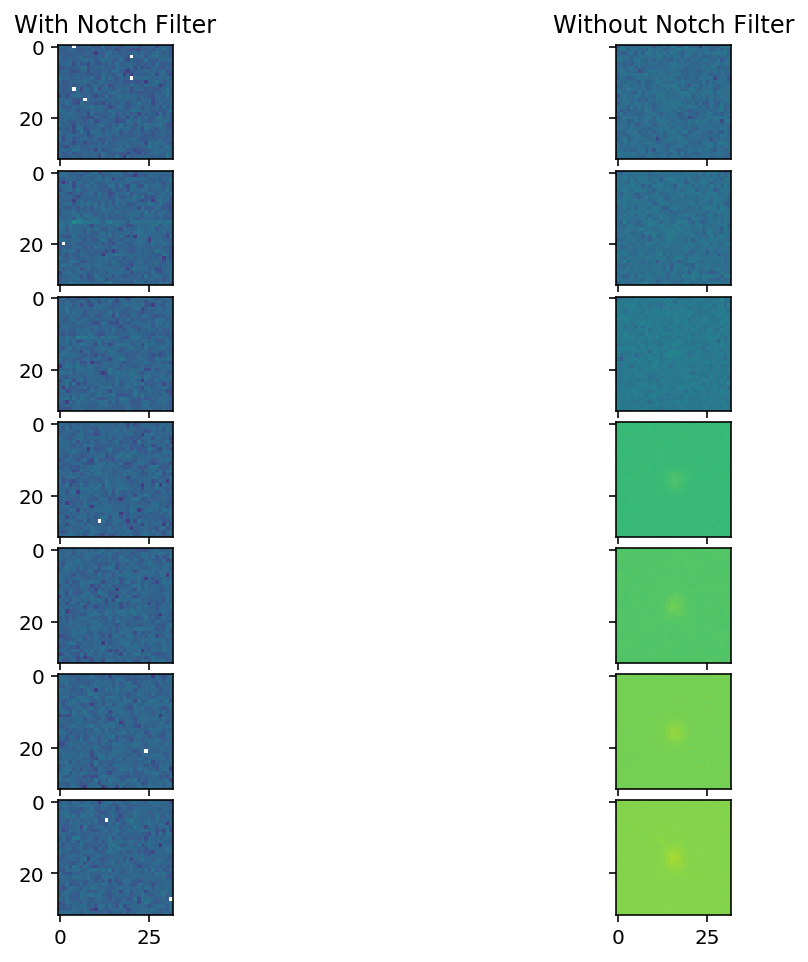

In [212]:
set_vmin = 0.1
set_vmax = 40000
set_norm = LogNorm(set_vmin, set_vmax)


fig, axs = plt.subplots(7, 2, sharex = True, sharey = True, gridspec_kw={'hspace': 0.1, 'wspace': 0})
#fig.set_size_inches(20, 20)

(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12), (ax13, ax14) = axs


ax1.imshow(intimage_w500, norm = set_norm)
ax1.set_title('With Notch Filter')
ax2.imshow(intimage_wo500, norm = set_norm)
ax2.set_title('Without Notch Filter')

ax3.imshow(intimage_w495, norm = set_norm)
ax4.imshow(intimage_wo495, norm = set_norm)

ax5.imshow(intimage_w493, norm = set_norm)
ax6.imshow(intimage_wo493, norm = set_norm)

ax7.imshow(intimage_w490, norm = set_norm)
ax8.imshow(intimage_wo490, norm = set_norm)

ax9.imshow(intimage_w489, norm = set_norm)
ax10.imshow(intimage_wo489, norm = set_norm)

ax11.imshow(intimage_w488, norm = set_norm)
ax12.imshow(intimage_wo488, norm = set_norm)

ax13.imshow(intimage_w485, norm = set_norm)
ax14.imshow(intimage_wo485, norm = set_norm)


#plt.savefig('../notebooks/ns_plot_lin.pdf', format = 'pdf')
plt.show()

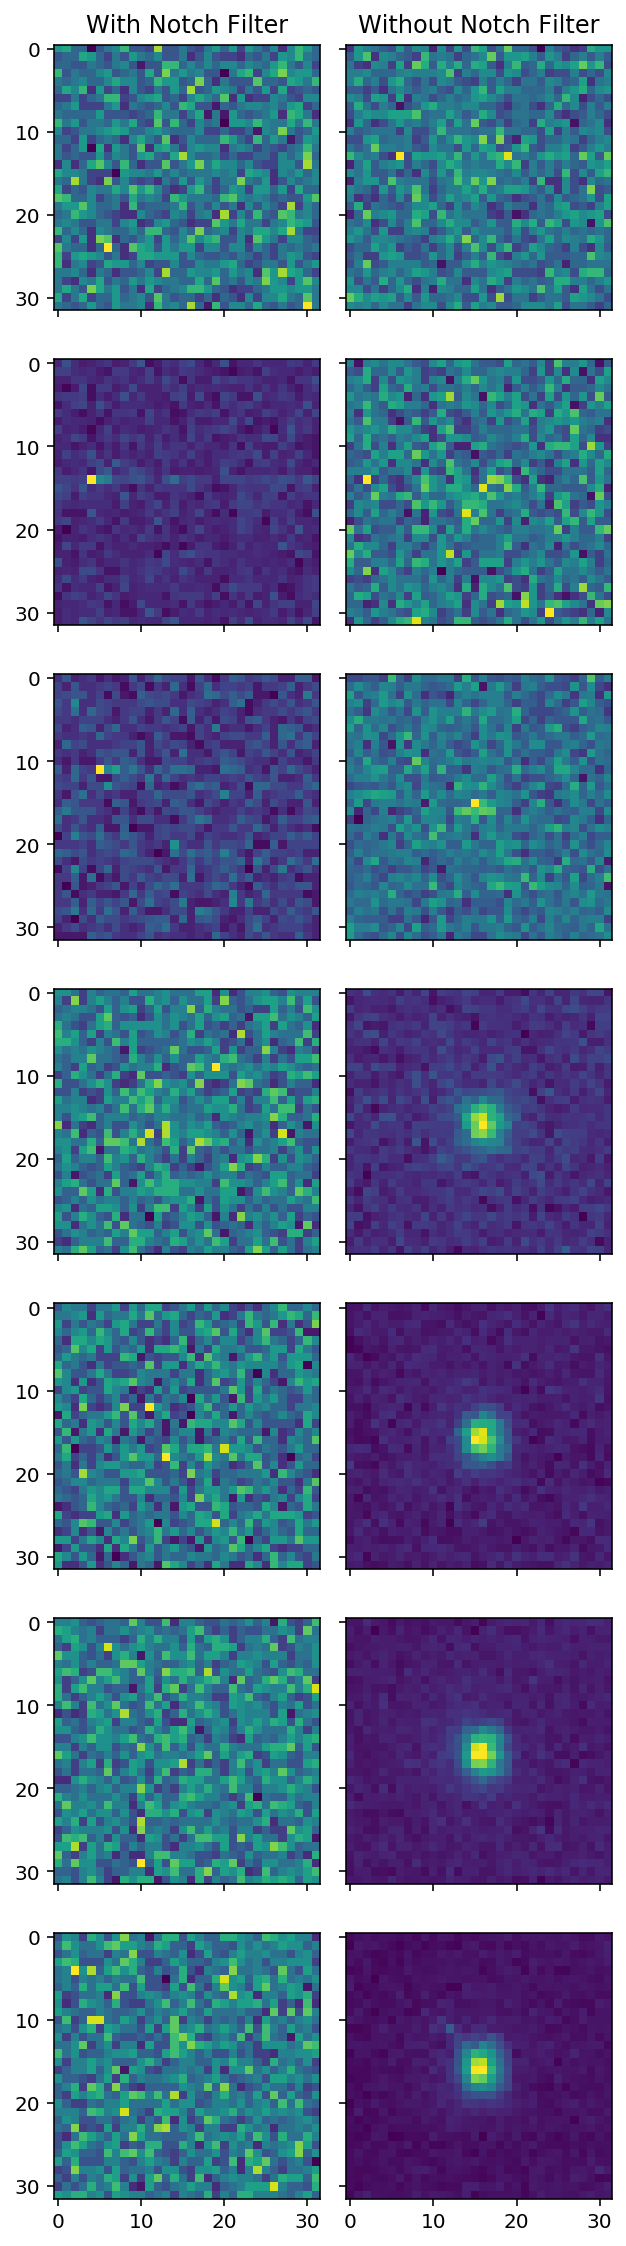

In [226]:
fig, axs = plt.subplots(7, 2, sharex = True, sharey = True, gridspec_kw={'hspace': 0.1, 'wspace': 0.1})
fig.set_size_inches(5, 20)

(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12), (ax13, ax14) = axs


ax1.imshow(intimage_w500)
ax1.set_title('With Notch Filter')
ax2.imshow(intimage_wo500)
ax2.set_title('Without Notch Filter')

ax3.imshow(intimage_w495)
ax4.imshow(intimage_wo495)

ax5.imshow(intimage_w493)
ax6.imshow(intimage_wo493)

ax7.imshow(intimage_w490)
ax8.imshow(intimage_wo490)

ax9.imshow(intimage_w489)
ax10.imshow(intimage_wo489)

ax11.imshow(intimage_w488)
ax12.imshow(intimage_wo488)

ax13.imshow(intimage_w485)
ax14.imshow(intimage_wo485)


plt.savefig('../notebooks/int_reconstructions.pdf', format = 'pdf')
plt.show()